## HW 1: Sinusoids, Functions, Additive Synthesis (15 points)
For each markdown cell, add a cell (or cells) of code below. 
Reminders:
* This is an individual assignment. 
* If you use GenAI tools to assist you with your homework, remember to fill out the GenAI Usage Statement at the bottom of the notebook. Even if you use GenAI, you should not be directly copying the code.
* You may only use functions/packages we have discussed in class

### Question 1 - Sinusoids (3 points)
Define the function, **genSine(f, ...)** that construct a sinusoid at frequency `f`.
The arguments should include:  
* amplitude, with default value of 1 (float)
* sample rate, with default value of 44.1kHz (float)
* time in seconds, with default value of 1 (float)
* phase offset, with default value of 0 (float)
    
and will return the numpy array containing the sinusoidal waveform.

Your function must check for appropriate input and handle any errors.
    

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio

#GLOBAL VARS

freq = 440
t = 1
numHarms = None
A =1
phi = 0
fs = 44100

def genSine(freq, duration = 1, A = 1, phi = 0, fs = 44100.0):
    try:
        if A <= 0:
            print("Ampltitude must be greater than zero!")
            return None
        if duration <= 0:
             print('Time must be longer than 0 seconds!')
             return None
        if freq>= (fs/2):
             print('Frequency must be less than half of the sampling rate!')
             
        t = np.arange(0, duration, 1/fs)
        x = A * np.sin(2*np.pi * freq * t + phi)
        return (x)
    except ZeroDivisionError:
            print('Frequency must be nonzero!')
    except TypeError:
         print('Arguments must be of type int or float')
    except InvalidInputError as e:
        print(e)
    


### Question 2 - Classical Waveform (5 points)
Define a function, **genWave(freq, t, numHarms=None, A=1, phi=0, fs=44100)**, that will create one of the fundamental waveforms (saw, triangle, or square) built from the combination of sinusoids at integer multiples of a fundamental frequency.  The arguments passed will be as follows:

* freq will be the frequency in Hz (int or float).
* t will be the length of time in seconds (int or float).
* numHarms will be the number of harmonics used. If no value is given (NoneType), you should create the maximum harmonics possible given the sampling rate

The function should return a numpy array. **You may not use existing waveform functions such as those in the `scipy` library.**

Your function must check for appropriate input and handle any errors.

Try to make your function as efficient as you can, but we will not take points off for a long run time. Be mindful by using NumPy functions rather than direct iteration.

*Hint: your function should use your genSine function

**Bonus: Expand this function to create any of the classical waveforms with a new argument "type" specifying which to build.

In [2]:


def genWave(freq, t = 1, numHarms=None, A = 1, phi = 0, fs = 44100):
    N = int(t*fs)
    saw = np.zeros(N)
    tArr = np.arange(N) / fs
    
    try:
        
        if numHarms == None:
                nyquist = fs/2
                numHarms = int(nyquist // freq)
        
        for harm in range(1, numHarms+1):
            saw += (1/harm) * genSine(harm*freq, duration=t, A=A, phi=phi, fs=fs)
         
    except TypeError:
         print('Arguments must be of type int or float')
    except ZeroDivisionError:
        print('Sampling Rate must be nonzero!')
    
    return saw/2
    




### Question 3 - Arpeggio (4 points)

Define the function arpegiateFreq(freq, dur), that will create a major scale arpeggio of a given frequency for a given length using your genWave() function. The arguments passed will be as follows:
* freq will be the starting/fundamental frequency in Hz (int or float)
* dur will be the length of time in seconds (int or float)

Reminder: a major scale arpeggio is built from the root, major third, and perfect 5th. You should divide the duration evenly amongst the three notes. 

The function should return a numpy array.

*Hint: your function will use the function(s) you just wrote*

Your function must check for appropriate input and handle any errors

**Bonus: Create a new function called arpegiateNote(scale, dur). Instead of the second input being frequency in Hz, the function should receive a note name like 'C'. You will need to convert this note to frequency. If you want to go the extra mile, make it case sensitive, such that an uppercase 'C' yields a C major arpeggio and lowercase 'c' yields a c minor arpeggio.

In [3]:
def arpeggiateFreq(freq1, dur = 1):

    sampInc = round(dur*fs / 3)
    nLen = np.zeros(dur * fs)

    n0 = 12 * np.log2(freq1/440) + 69
    freq2  = freq1*(2**(4/12))
    freq3 = freq1*(2**(7/12))

    arr1 = genWave(freq1, t=(dur/3), numHarms=numHarms, A=A, phi=phi, fs=fs)
    arr2 = genWave(freq2, t=(dur/3), numHarms=numHarms, A=A, phi=phi, fs=fs)
    arr3 = genWave(freq3, t=(dur/3), numHarms=numHarms, A=A, phi=phi, fs=fs)

    
    genArr = np.concatenate((arr1,arr2,arr3))
    
    return genArr



## Error handling tips and edge cases
What should happen if the frequency inputs to our functions would generate frequncies above Nyquist?

What should happen if our time inputs are negative? Or are 0?

What should happen if our frequencies are negative? Or are 0?

You should account for actual coding errors and errors that conceptually do not make sense.

### Section 4 - Using functions and graphing (3 points)
Create a 2 second F major arpeggio in an array named 'myArp'. Play back your audio.

In [4]:
myArp = arpeggiateFreq(349.23, 2) # Arps keep throwing errors 

Audio(myArp, rate = fs)

#len(myArp)

Remove every 4th sample of 'myArp', save as a new array, 'skipped, and play back your audio. What happened to the audio?

In [5]:
skipped = np.delete(myArp, np.arange(3, len(myArp), 4))

Audio(skipped, rate=fs)



Create a 2 Bb major arpeggio in an array named 'myArp2'. Play back your audio

In [6]:
myArp2 = arpeggiateFreq(466.16, 2) # Arps keep throwing errors 

Audio(myArp2, rate=fs)



Reverse 'myArp2' and save as a new array, 'reverse'. Play back your audio

In [7]:
reverse = myArp2[-1:0:-1]
Audio(reverse, rate=fs)



Graph your 4 arrays on top of one another. Make sure to label the axis and plot against time. 

Text(0.5, 1.0, 'Sinusoids Plotted on Each Other')

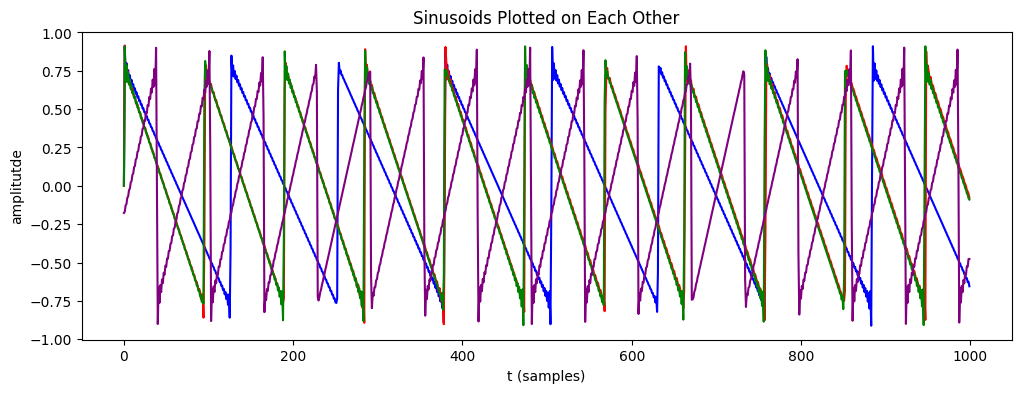

In [8]:

#RESIZE ARRAYS  TO FIT 2 SECONDS\
skipped = np.pad(skipped, (0, 88200 - len(skipped)))
reverse = np.pad(reverse, (0, 88200 - len(reverse)))


tSize = 1000 #len(myArp)

plt.figure(figsize=(12,4))

plt.plot(myArp[:tSize], label='myArp', color='blue', linestyle='-')

plt.plot(skipped[:tSize], label='skipped', color='red', linestyle='-')

plt.plot(myArp2[:tSize], label='myArp2', color='green', linestyle='-')

plt.plot(reverse[:tSize], label='reverse', color='purple', linestyle='-')

plt.xlabel('t (samples)')

plt.ylabel('amplitutde')

plt.title('Sinusoids Plotted on Each Other')




Create another graph, but this time only plot the first "note" of each array

Text(0.5, 1.0, 'Sinusoids Plotted on Each Other')

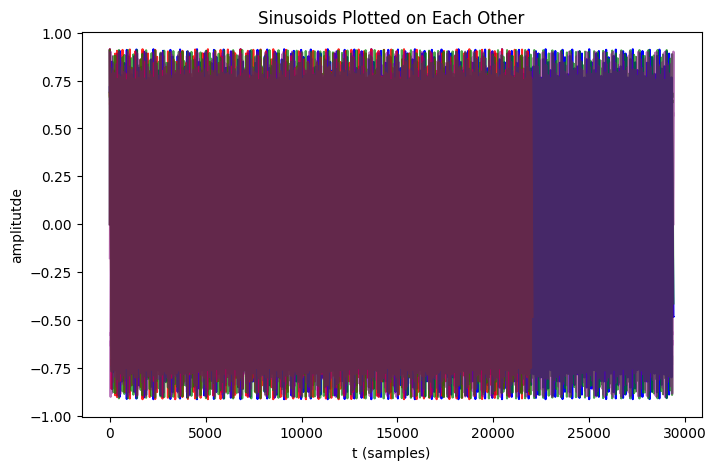

In [9]:
tSize = int(len(myArp) / 3)

plt.figure(figsize=(8,5))

plt.plot(myArp[:tSize], label='myArp', color='blue', linestyle='-',)

plt.plot(skipped[:round((.75*tSize))], label='myArpR', color='red', linestyle='-', alpha=0.85) #skipped note length is shorter

plt.plot(myArp2[:tSize], label='myArp2', color='green', linestyle='-', alpha=0.70)

plt.plot(reverse[:tSize], label='myArp2R', color='purple', linestyle='-', alpha=0.55)

plt.xlabel('t (samples)')

plt.ylabel('amplitutde')

plt.title('Sinusoids Plotted on Each Other')



### GenAI Usage Statement (if applicable)

Date: 01/30/26
Prompt (Google Search): how to pad an array with zeros python
Result: 

Using numpy.pad() (Recommended for Arrays) 
The numpy.pad() function is highly flexible and the standard method for padding NumPy arrays. The default mode is 'constant', which uses a default constant_values of 0, making it ideal for this task. 
For a 1D array:
python
import numpy as np

arr = np.array([1, 2, 3, 4, 5])
# Pad with 2 zeros at the beginning and 3 zeros at the end
padded_arr = np.pad(arr, (2, 3), 'constant')

print(padded_arr)
# Output: [0 0 1 2 3 4 5 0 0 0]
The pad_width argument (2, 3) specifies the number of zeros to add before and after the array, respectively.
For a 2D array:
python
import numpy as np

arr_2d = np.array([[1, 2], [3, 4]])
# Pad with 1 zero on top/bottom, and 2 zeros on left/right
# pad_width format is ((top, bottom), (left, right))
padded_arr_2d = np.pad(arr_2d, ((1, 1), (2, 2)), 'constant')

print(padded_arr_2d)
# Output:
# [[0 0 0 0 0 0]
#  [0 0 1 2 0 0]
#  [0 0 3 4 0 0]
#  [0 0 0 0 0 0]]
If you want uniform padding around the entire array, you can simply pass a single integer or tuple pad_width=1. 
Alternative Methods
Creating a New Array and Filling (For Specific Target Shape)
If you know the desired final shape of your array in advance, you can create a new array of zeros and insert the original array into it. This is efficient when the target shape is significantly larger. 
python
import numpy as np

original_array = np.array([1, 2, 3])
target_length = 5

# Create a new array of zeros with the target length
padded_array = np.zeros(target_length, dtype=original_array.dtype)

# Insert the original array into the new one
padded_array[:len(original_array)] = original_array

print(padded_array)
# Output: [1 2 3 0 0]
For Python Lists
If you are working with a standard Python list (not a NumPy array), you can use simple list concatenation. 
python
my_list = [1, 2, 3]
num_zeros_to_add = 2

# Add zeros to the end of the list
padded_list = my_list + [0] * num_zeros_to_add

print(padded_list)
# Output: [1, 2, 3, 0, 0]

Use Case: Used this to find a way to extend my skipped array to fit the dimensions of my plot

USAGE 2:

Date: 01/30/26
Prompt (Google Search): delete values from a numpy array

Result: To delete values from a NumPy array, you can use the numpy.delete() function or Boolean indexing (masking). Note that NumPy arrays are fixed-size, so these methods return a new array with the specified values removed; they do not modify the original array in-place. 
Using numpy.delete()
The np.delete() function removes elements by their index or position along a specified axis. 
Delete by Index in a 1D Array 
You can remove single or multiple elements by specifying their indices. 
python
import numpy as np

arr_1d = np.array([1, 2, 3, 4, 5, 6])

# Delete a single element at index 2 (value 3)
new_arr_single = np.delete(arr_1d, 2)
print(f"After single delete: {new_arr_single}")

# Delete multiple elements at indices 0 and 4 (values 1 and 5)
indices_to_delete = [0, 4]
new_arr_multiple = np.delete(arr_1d, indices_to_delete)
print(f"After multiple delete: {new_arr_multiple}")
Output:
After single delete: [1 2 4 5 6]
After multiple delete: [2 3 4 6]
 
Delete Rows or Columns in a 2D Array 
Use the axis parameter to specify whether to delete rows (axis=0) or columns (axis=1). 
python
arr_2d = np.array([[1, 2, 3], 
                   [4, 5, 6], 
                   [7, 8, 9]])

# Delete the second row (index 1)
new_arr_row = np.delete(arr_2d, 1, axis=0)
print(f"After row delete:\n{new_arr_row}")

# Delete the third column (index 2)
new_arr_col = np.delete(arr_2d, 2, axis=1)
print(f"\nAfter column delete:\n{new_arr_col}")
Output:
After row delete:
[[1 2 3]
 [7 8 9]]

After column delete:
[[1 2]
 [4 5]
 [7 8]]
 
Using Boolean Indexing
This method creates a new array by selecting only the elements that meet a certain condition. This is useful when you want to remove elements based on their value rather than their index. 
Delete by Value in a 1D Array 
python
import numpy as np

arr_1d = np.array([1, 2, 3, 4, 3, 5, 3])
value_to_delete = 3

# Create a new array that only includes values NOT equal to 3
# The condition `arr_1d != value_to_delete` creates a boolean mask
new_arr_by_value = arr_1d[arr_1d != value_to_delete]
print(f"After deleting value {value_to_delete}: {new_arr_by_value}")
Output:
After deleting value 3: [1 2 4 5]
 
Delete based on a list of values
You can also use np.isin() to remove elements that are present in a separate list of values. 
python
import numpy as np

a = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
values_to_remove = [3, 4, 7]

# Create a mask where elements of 'a' are NOT in 'values_to_remove'
# The `~` operator negates the boolean mask
mask = ~np.isin(a, values_to_remove)
new_a = a[mask]

print(f"Original array: {a}")
print(f"Values to remove: {values_to_remove}")
print(f"Array after removal: {new_a}")
Output:
Original array: [1 2 3 4 5 6 7 8 9]
Values to remove: [3, 4, 7]
Array after removal: [1 2 5 6 8 9]


Use Case: Used to skip every fourth value in an array.


